# HW2 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hw2_loader import HW2DataLoader
from model import GradientBoostingModel
from hw1_model import LogisticClassifier
from sklearn.metrics import confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [6]:
# TODO: Load both datasets
loader = HW2DataLoader()

# Heart disease dataset
heart_path = Path('../data/heart.csv')
X_heart, y_heart = loader.get_heart_disease_data(csv_path=heart_path)
print(X_heart.shape, y_heart.value_counts().to_dict())

# Cancer genomics dataset
cancer_path = Path('../data/cancer_genomics.csv')
labels_path = Path('../data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)
print(X_cancer.shape, y_cancer.value_counts().to_dict())


Successfully loaded heart disease data with 1025 rows
(1025, 13) {1: 526, 0: 499}
(801, 5479) {'BRCA': 300, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136, 'COAD': 78}


In [7]:
# Feature exploration
X_cancer.max().max(), X_cancer.min().min(), X_cancer.mean().mean(), X_cancer.std().std()
(X_cancer == 0).sum().sum()
# X_cancer.duplicated().sum()
# X_heart.duplicated().sum()

np.int64(405815)

In [8]:
# Preprocessing
X_cancer = X_cancer.fillna(X_cancer.mean())
X_heart = X_heart.fillna(X_heart.mean())

# Find duplicates
X_cancer_duplicates = X_cancer[X_cancer.duplicated()].index
X_heart_duplicates = X_heart[X_heart.duplicated()].index

X_cancer = X_cancer.drop(index=X_cancer_duplicates)
y_cancer = y_cancer.drop(index=X_cancer_duplicates)

X_heart = X_heart.drop(index=X_heart_duplicates)
y_heart = y_heart.drop(index=X_heart_duplicates)    

print(X_cancer.shape)
print(X_heart.shape)

(801, 5479)
(302, 13)


In [121]:
# TODO: Initialize your model (adjust params)
model = GradientBoostingModel(
    task='classification',
    max_depth=3,
    learning_rate=0.1,
    n_estimators=50,
    use_scaler=False,
    multi_class=False
)


In [122]:
# TODO: Train/test split + fit (heart)
# X_train, X_test, y_train, y_test = model.train_test_split(...)
# model.fit(X_train, y_train)
X_train, X_test, y_train, y_test = model.train_test_split(X_heart, y_heart)
model.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.2703            0.06s
         2           1.1801            0.04s
         3           1.1056            0.04s
         4           1.0373            0.03s
         5           0.9800            0.03s
         6           0.9292            0.03s
         7           0.8836            0.03s
         8           0.8433            0.03s
         9           0.8064            0.02s
        10           0.7742            0.02s
        20           0.5509            0.02s
        30           0.4263            0.01s
        40           0.3445            0.01s
        50           0.2891            0.00s


In [123]:
# TODO: Evaluate (heart)
# metrics = model.evaluate(...)
# print metrics

metrics = model.evaluate(X_test, y_test)
print(metrics)

{'accuracy': 0.7540983606557377, 'precision': 0.7537054894817672, 'recall': 0.7540983606557377, 'f1': 0.7536979780679315, 'roc_auc': 0.8452380952380953}


,Features,Importance
2,cp,0.351482
11,ca,0.131489
12,thal,0.115954
7,thalach,0.076780
9,oldpeak,0.074977
0,age,0.058415
8,exang,0.044603
1,sex,0.041847
4,chol,0.039994
3,trestbps,0.026305


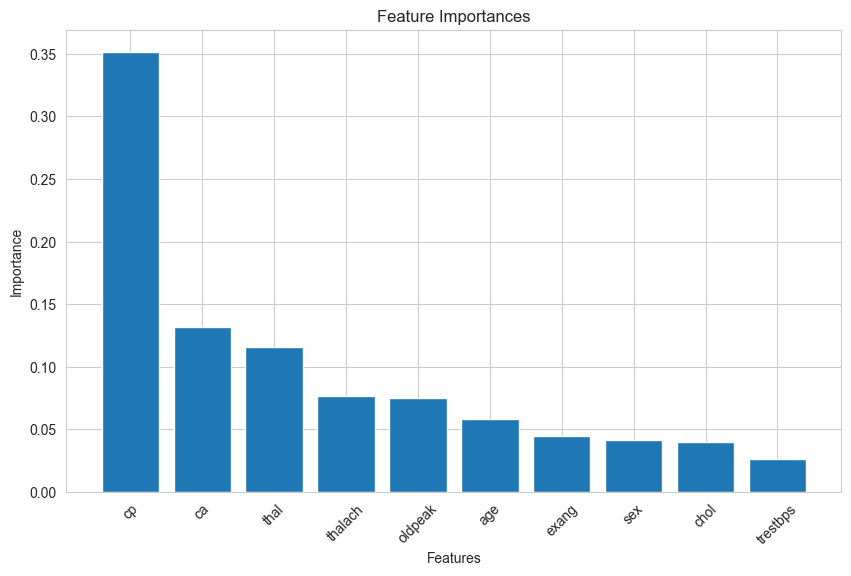

In [124]:
model.get_feature_importance(top_n = 10, plot=True)

In [126]:
# TODO: Cross-validation (heart)
# cv_results = model.cross_validate(...)
# print metrics
cv_results = model.cross_validate(X_train, y_train)
cv_table = pd.DataFrame(cv_results)
print(cv_table)

      Iter       Train Loss   Remaining Time 
         1           1.2686            0.06s
         2           1.1778            0.04s
         3           1.0963            0.03s
         4           1.0296            0.04s
         5           0.9670            0.05s
         6           0.9119            0.04s
         7           0.8666            0.04s
         8           0.8257            0.04s
         9           0.7811            0.04s
        10           0.7427            0.03s
        20           0.5032            0.02s
        30           0.3686            0.01s
        40           0.2813            0.01s
        50           0.2255            0.00s
      Iter       Train Loss   Remaining Time 
         1           1.2648            0.02s
         2           1.1738            0.02s
         3           1.0988            0.02s
         4           1.0275            0.02s
         5           0.9653            0.02s
         6           0.9081            0.02s
        

    Features  Importance
2         cp    0.351482
11        ca    0.131489
12      thal    0.115954
7    thalach    0.076780
9    oldpeak    0.074977
0        age    0.058415
8      exang    0.044603
1        sex    0.041847
4       chol    0.039994
3   trestbps    0.026305


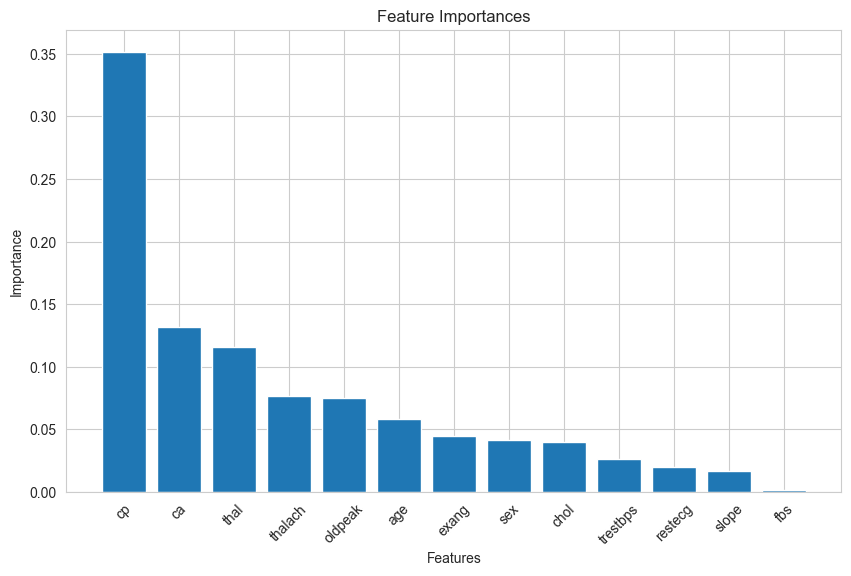

In [125]:
# TODO: Feature importance (heart)
# model.get_feature_importance(plot=False)
feature_importance = model.get_feature_importance(plot=True)
print(feature_importance.head(10))


In [129]:
# TODO: Hyperparameter tuning (heart)
param_grid = {
    'max_depth': [2,3,5,10],
    'n_estimators': [10,30,50],
    'learning_rate': [0.05, 0.1, 0.2]
}
tuning_results = model.tune_hyperparameters(X_heart, y_heart, param_grid, cv=3)


# sns.heatmap(mean_score_df, annot=True, cmap="turbo")
# plt.title("Grid Search CV Mean Score")
# plt.ylabel("max_depth")
# plt.xlabel("n_estimators")
# plt.show()

      Iter       Train Loss   Remaining Time 
         1           1.3335            0.01s
         2           1.2924            0.00s
         3           1.2551            0.00s
         4           1.2212            0.00s
         5           1.1904            0.00s
         6           1.1621            0.00s
         7           1.1323            0.00s
         8           1.1076            0.00s
         9           1.0814            0.00s
        10           1.0594            0.00s
      Iter       Train Loss   Remaining Time 
         1           1.3420            0.00s
         2           1.3080            0.00s
         3           1.2771            0.00s
         4           1.2483            0.00s
         5           1.2216            0.00s
         6           1.1955            0.00s
         7           1.1719            0.00s
         8           1.1490            0.00s
         9           1.1281            0.00s
        10           1.1079            0.00s
      It

In [132]:
grid_search_table = pd.DataFrame(tuning_results.cv_results_)
best_results = grid_search_table['mean_test_roc_auc'].idxmax()
best_statistics = grid_search_table.loc[best_results]

print(best_statistics)

mean_fit_time                                                     0.017045
std_fit_time                                                      0.000641
mean_score_time                                                   0.004324
std_score_time                                                     0.00027
param_learning_rate                                                   0.05
param_max_depth                                                          2
param_n_estimators                                                      50
params                   {'learning_rate': 0.05, 'max_depth': 2, 'n_est...
split0_test_accuracy                                              0.792079
split1_test_accuracy                                              0.861386
split2_test_accuracy                                                  0.79
mean_test_accuracy                                                0.814488
std_test_accuracy                                                 0.033173
rank_test_accuracy       

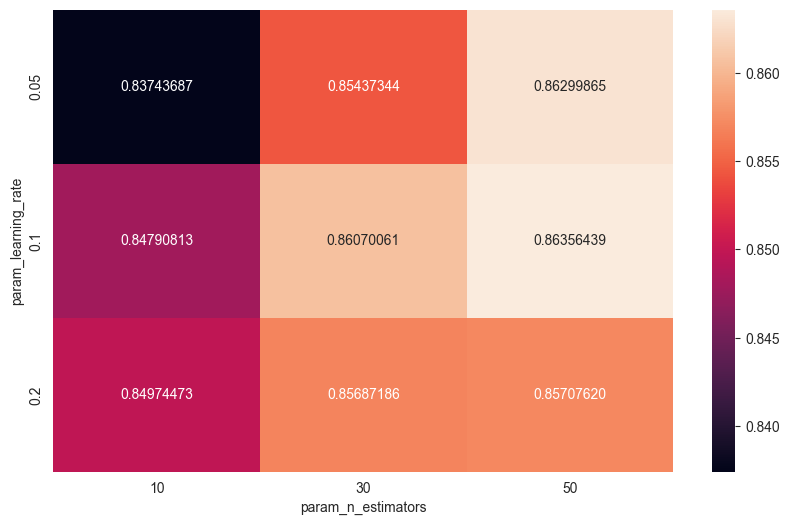

In [133]:
# Grid search heatmap
fine_tune_plot = grid_search_table.groupby(['param_learning_rate', 'param_n_estimators'])['mean_test_roc_auc'].mean().unstack()
sns.heatmap(fine_tune_plot, annot=True, fmt='.8f')
plt.show()

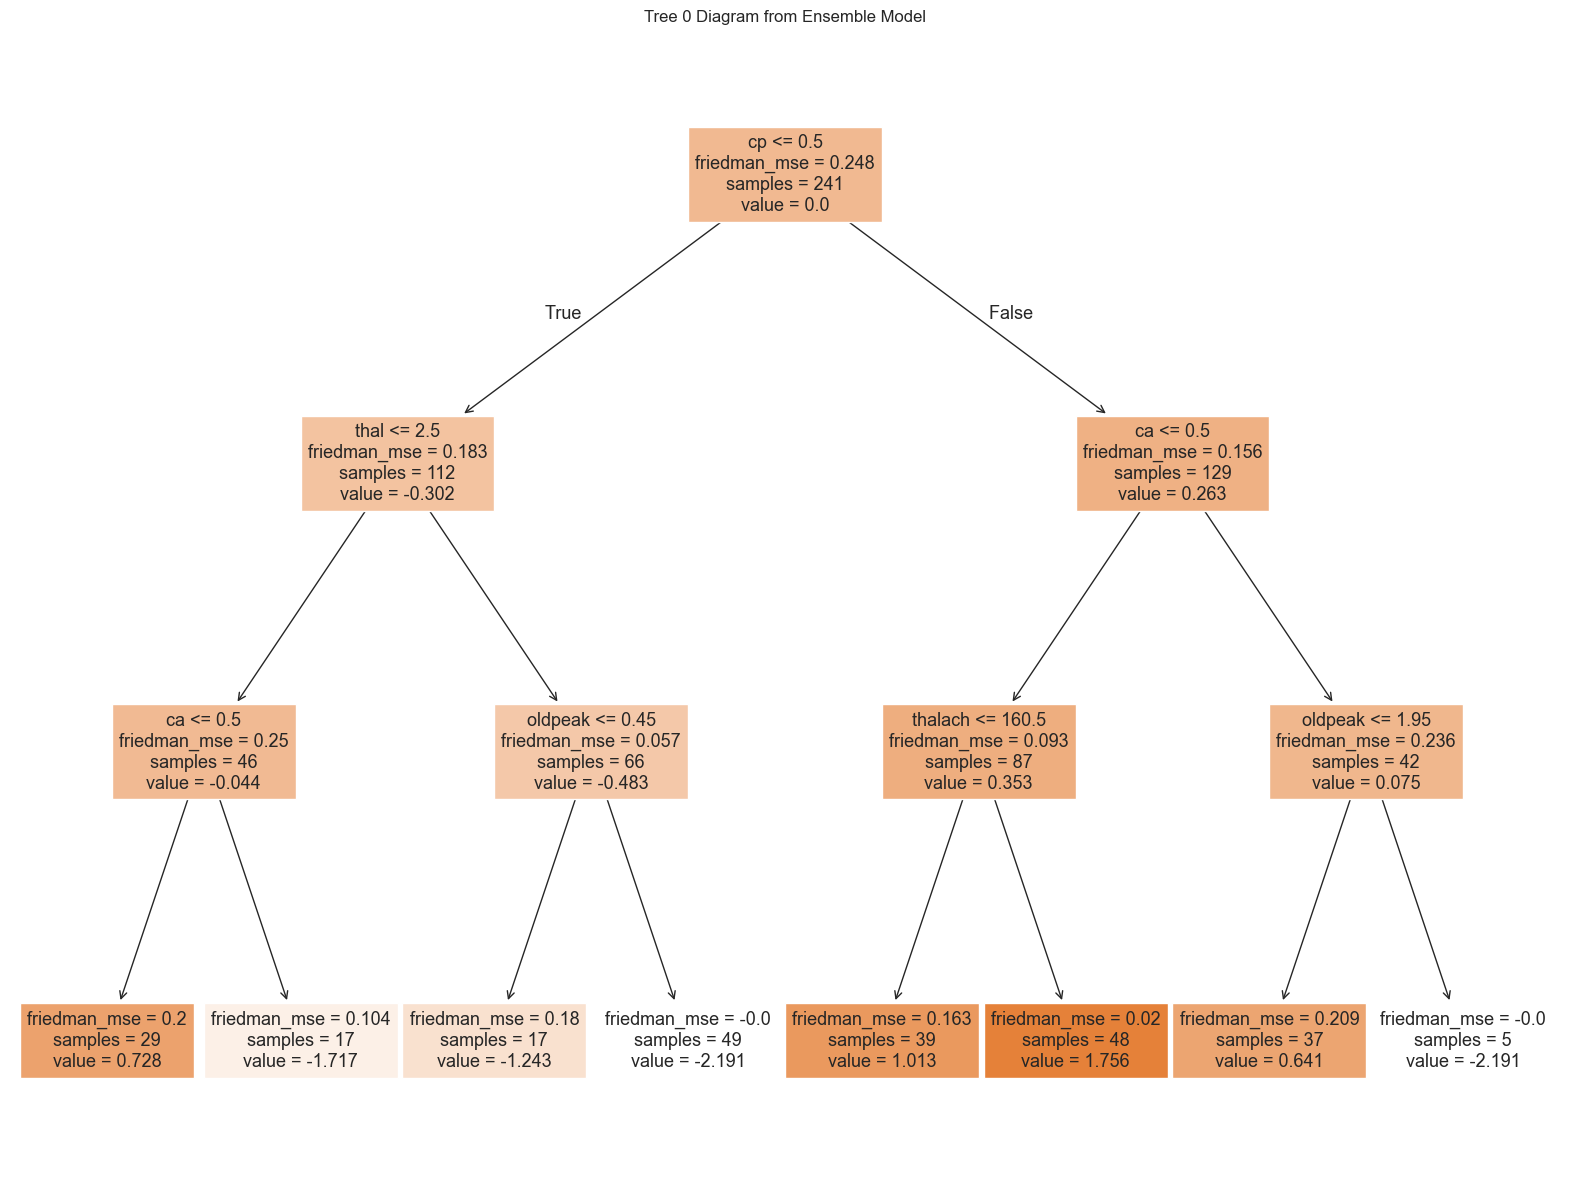

In [136]:
model.plot_tree(tree_index=0, figsize=(20, 15))

In [60]:
# TODO: Train/evaluate on cancer dataset (multi-class)
# cancer_model = GradientBoostingModel(...)
# cancer_model.train_test_split(...)
# fit
# evaluate 
# print metrics

cancer_model = GradientBoostingModel(
    task='classification',
    max_depth=2,
    learning_rate=0.2,
    n_estimators=70,
    subsample=0.5,
    min_samples_leaf=5,
    use_scaler=False,
    multi_class=True,
)

X_train, X_test, y_train, y_test = cancer_model.train_test_split(X_cancer, y_cancer)

cancer_model.fit(X_train, y_train)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.8260           0.6487           45.94s
         1           0.8260           0.6487           45.94s
         2           0.5488           0.2686           49.88s
         2           0.5488           0.2686           49.88s
         3           0.3903           0.1835           51.18s
         3           0.3903           0.1835           51.18s
         4           0.2725           0.1045           51.18s
         4           0.2725           0.1045           51.18s
         5           0.1991           0.0811           51.20s
         5           0.1991           0.0811           51.20s
         6           0.1439           0.0547           50.65s
         6           0.1439           0.0547           50.65s
         7           0.1048           0.0372           49.91s
         7           0.1048           0.0372           49.91s
         8           0.0811           0.0352           49.20s
       

In [100]:
cancer_metrics = cancer_model.evaluate(X_test, y_test)

print(cancer_metrics)

{'accuracy': 0.9813664596273292, 'precision': 0.9822537710736469, 'recall': 0.9813664596273292, 'f1': 0.9810663335743869, 'roc_auc': 1.0}


In [41]:
# Cross validate Cancer Dataset
cv_results = cancer_model.cross_validate(X_train, y_train)
cv_table = pd.DataFrame(cv_results)
print(cv_table)

      Iter       Train Loss   Remaining Time 
         1           0.8127            9.74s
         2           0.5410           15.81s
         3           0.3740           15.52s
         4           0.2633           14.45s
         5           0.1873           12.54s
         6           0.1341           10.29s
         7           0.0964            7.81s
         8           0.0695            5.25s
         9           0.0502            2.64s
        10           0.0364            0.00s
      Iter       Train Loss   Remaining Time 
         1           0.8136            9.11s
         2           0.5416           14.72s
         3           0.3744           14.34s
         4           0.2636           13.12s
         5           0.1875           11.54s
         6           0.1342            9.42s
         7           0.0965            7.14s
         8           0.0696            4.81s
         9           0.0503            2.43s
        10           0.0364            0.00s
      It

Text(0.5, 1.0, 'Confusion Matrix')

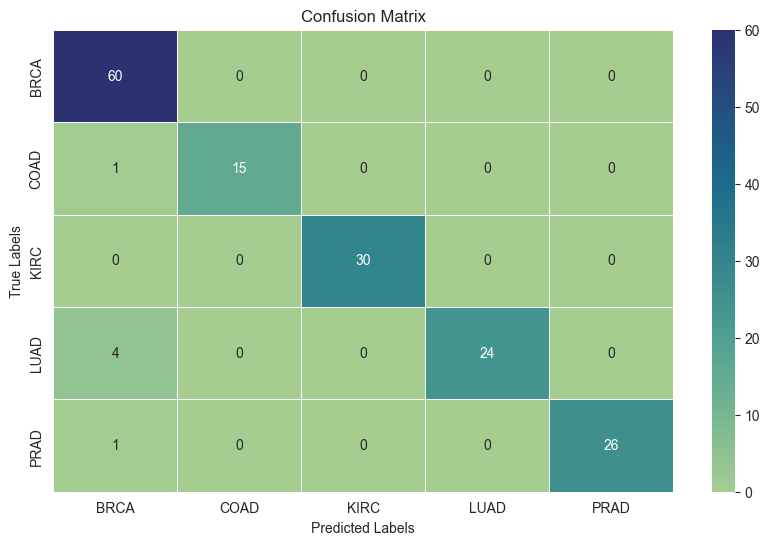

In [105]:
# Multi-class confusion matrix
class_names = list(cancer_model.model.classes_)
confusion = confusion_matrix(y_test, cancer_model.predict(X_test))
sns.heatmap(confusion, annot=True, fmt=".0f", linewidth=.5, xticklabels=class_names, yticklabels=class_names, cmap="crest")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

,Features,Importance
2351,gene_7964,0.132207
57,gene_203,0.097795
4100,gene_14503,0.091817
4435,gene_15896,0.087670
4908,gene_17801,0.083932
5167,gene_18746,0.076454
4434,gene_15895,0.071729
3498,gene_12013,0.052173
957,gene_3439,0.049518
5004,gene_18135,0.043333


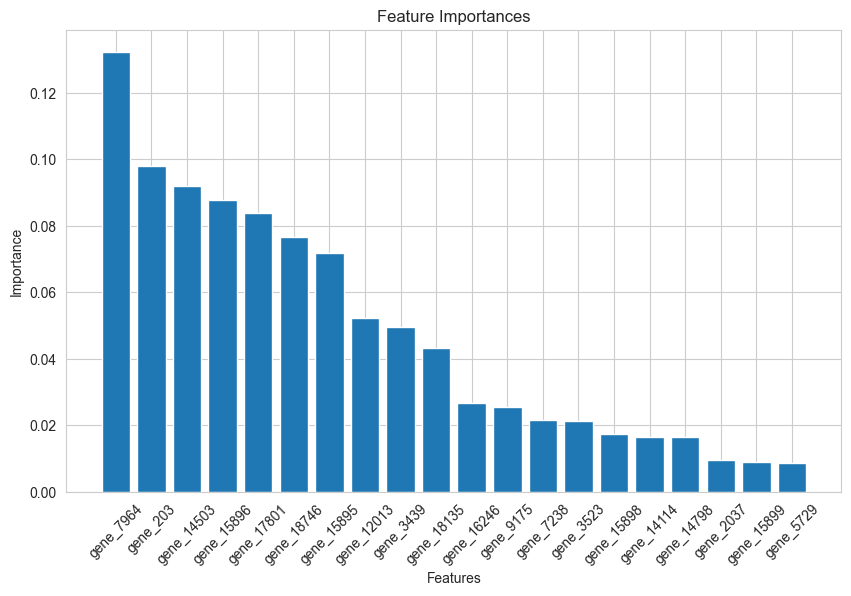

In [80]:
cancer_model.get_feature_importance(top_n = 20, plot=True)


In [48]:
param_grid = {
    'max_depth': [2,5,10],
    'n_estimators': [30,50,70],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.5, 1.0],
    'min_samples_leaf': [2, 5]
}
tuning_results = cancer_model.tune_hyperparameters(X_cancer, y_cancer, param_grid, cv=3)
grid_search_table = pd.DataFrame(tuning_results.cv_results_)
print(tuning_results)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.1335           0.3595           15.45s
         2           0.9105           0.2417           17.22s
         3           0.7410           0.1579           17.36s
         4           0.6122           0.1249           16.90s
         5           0.5159           0.1052           16.36s
         6           0.4334           0.0831           15.78s
         7           0.3726           0.0775           15.24s
         8           0.3144           0.0577           14.62s
         9           0.2663           0.0475           13.96s
        10           0.2241           0.0389           13.29s
        20           0.0465           0.0089            6.74s
        30           0.0115           0.0030            0.00s
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.1477           0.3647           16.03s
         2           0.9081           0.2141           19.57s
      

In [77]:
results_df = pd.DataFrame(tuning_results.cv_results_)
best_results = results_df['mean_test_roc_auc_ovr_weighted'].idxmax()
best_statistics = results_df.loc[best_results]

print(best_statistics)


mean_fit_time                                                               46.629206
std_fit_time                                                                 0.173004
mean_score_time                                                              0.068771
std_score_time                                                               0.004368
param_learning_rate                                                               0.2
param_max_depth                                                                     2
param_min_samples_leaf                                                              5
param_n_estimators                                                                 70
param_subsample                                                                   0.5
params                              {'learning_rate': 0.2, 'max_depth': 2, 'min_sa...
split0_test_accuracy                                                         0.996255
split1_test_accuracy                                  

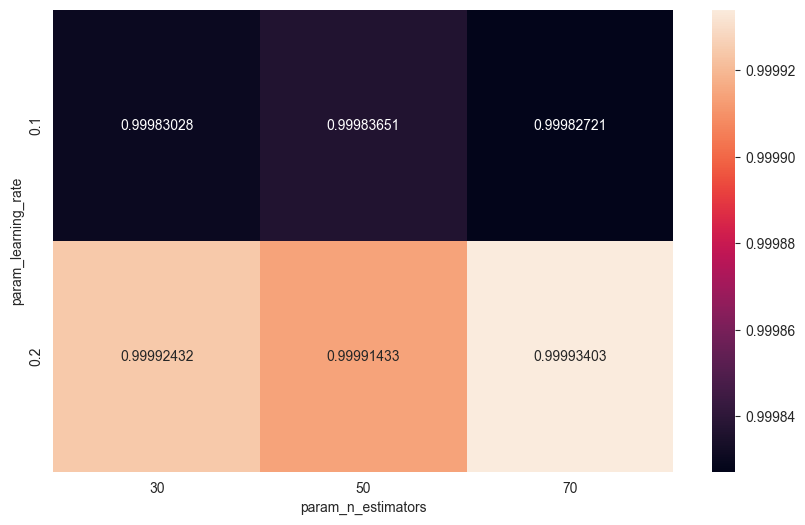

In [76]:
# Grid search heatmap
fine_tune_plot = grid_search_table.groupby(['param_learning_rate', 'param_n_estimators'])['mean_test_roc_auc_ovr_weighted'].mean().unstack()
sns.heatmap(fine_tune_plot, annot=True, fmt='.8f')
plt.show()

In [81]:
# Compare with HW 1 model
logistics_model = LogisticClassifier()
logistics_model.fit(X_train, y_train)

In [82]:
logistics_model.evaluate(X_test, y_test)

{'accuracy': 0.9937888198757764,
 'precision': 0.9938906425007638,
 'recall': 0.9937888198757764,
 'f1': 0.993758020635491,
 'auc': nan}

In [109]:
# Training Logistics Model with only Top 5 features
top_5_features = ["gene_7964", "gene_203", "gene_14503", "gene_15896", "gene_17801"]
top_20_features = ["gene_7964", "gene_203", "gene_14503", "gene_15896", "gene_17801", "gene_18746", "gene_15895", "gene_12013", "gene_3439", "gene_18135", "gene_16246", "gene_9175", "gene_7238", "gene_3523", "gene_15898", "gene_14114", "gene_14798", "gene_2037", "gene_15899", "gene_5729"]
logistics_model = LogisticClassifier()

X_train2, X_test2, y_train2, y_test2 = cancer_model.train_test_split(
    X_cancer[top_5_features], y_cancer
)

logistics_model.fit(X_train2, y_train2)

In [110]:
logistics_model.evaluate(X_test2, y_test2)

{'accuracy': 0.9813664596273292,
 'precision': 0.9843085975809087,
 'recall': 0.9813664596273292,
 'f1': 0.9818823591010136,
 'auc': 1.0}